# Phase 8.1: Neural Mosaic Reconstruction (Structural Shade Matching)
This algorithm abandons Deep Learning and instead uses Data Science algorithms (`scipy` KD-Trees) to physically chop up the Style Image into thousands of puzzle pieces.

**The Magic Trick:** It measures the shadows and depths of the Content Image in Grayscale, then finds an Icarus puzzle piece with the exact same depth, and glues the original vibrant RGB puzzle piece onto the canvas! This allows Conor to be built entirely out of bright blues and oranges, while perfectly preserving his original facial structure!

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
from PIL import Image

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.models.mosaic_engine import MosaicEngine

In [ ]:
# 1. Initialize the Engine
# Set tile_size to 5 for high-res face, or 10 to see chunkier brush strokes!
engine = MosaicEngine(tile_size=5, stride=2)

# 2. Run the Engine
content_path = '../data/content_images/mcgregor.jpg'
style_path = '../data/style_images/icarus.jpg'

# This will run ENTIRELY on your CPU and should finish in just a few seconds!
final_mosaic = engine.run(content_path, style_path, output_size=(400, 400))

Loading images and resizing to (400, 400)...
Extracting puzzle pieces from Style Image...
Extracted 39204 unique puzzle pieces!
Building the KD-Tree Index (Librarian)...
Reconstructing Content Image using Style pieces...
Reconstruction Complete!


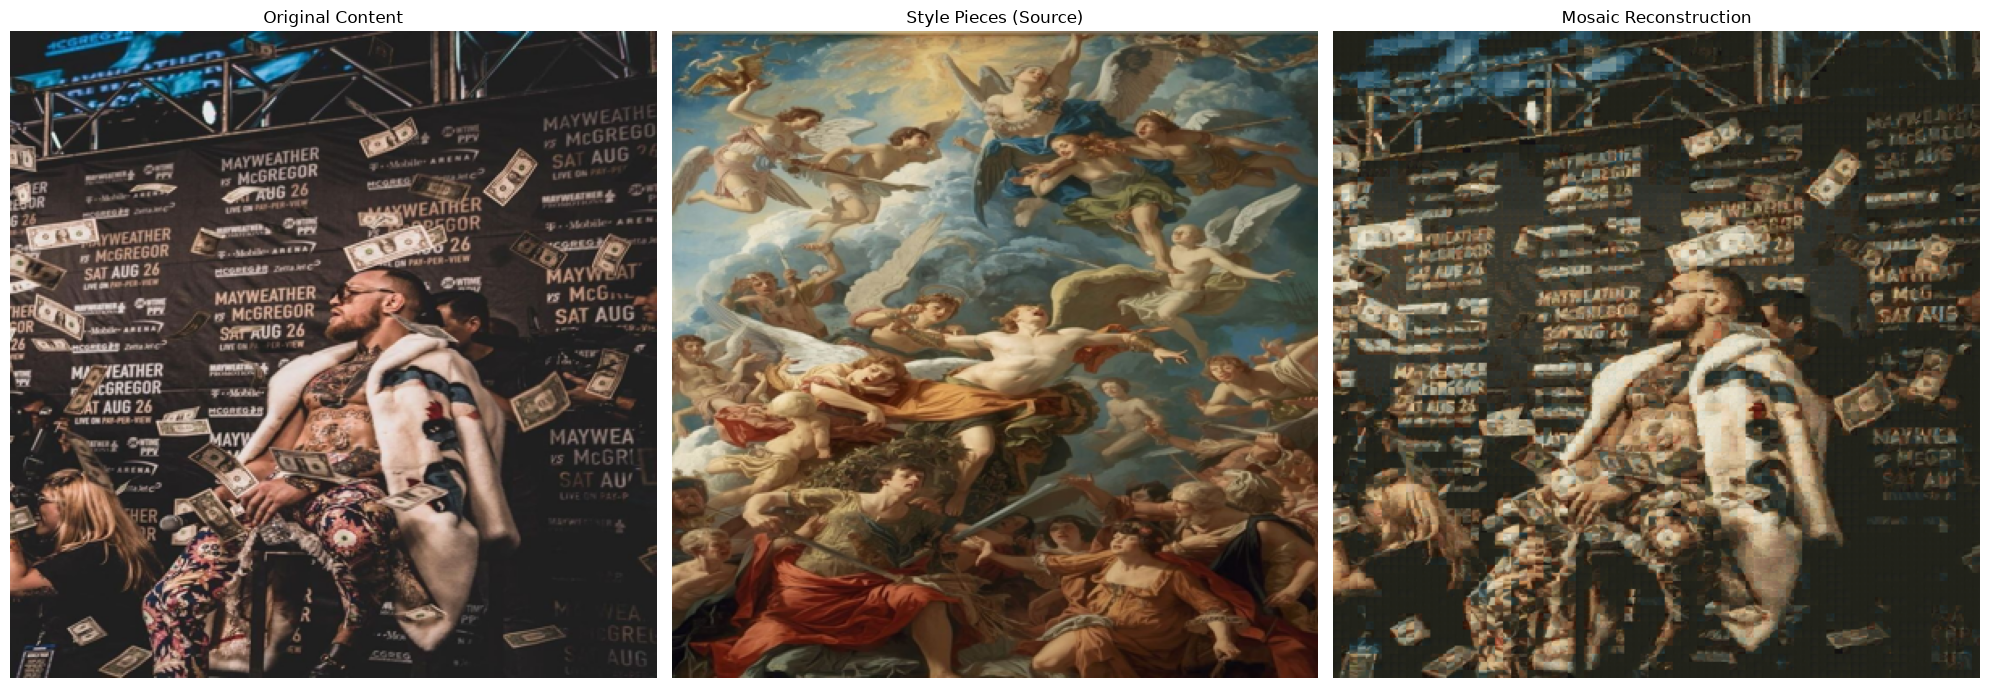

In [ ]:
# 3. Display the Masterpiece alongside the Originals
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

axs[0].imshow(Image.open(content_path).resize((400, 400)))
axs[0].set_title('Original Content')
axs[0].axis('off')

axs[1].imshow(Image.open(style_path).resize((400, 400)))
axs[1].set_title('Style Pieces (Source)')
axs[1].axis('off')

axs[2].imshow(final_mosaic)
axs[2].set_title('Mosaic Reconstruction')
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Optional: Save the masterpiece to disk
os.makedirs('../outputs', exist_ok=True)
final_mosaic.save('../outputs/mcgregor_mosaic.jpg')
print("Masterpiece saved to outputs folder!")

Masterpiece saved to outputs folder!
